# SER - Exploratory Data Analysis

In [2]:
# built-in imports
import sys
import os
# src imports
module_path = os.path.abspath(os.path.join('..', '..')) 
sys.path.insert(0, module_path)
from src.data_loading import load_emodb, load_ravdess, load_tess, load_crema_d, filter_emotions, load_iemocap
# 
import numpy as np
import pandas as pd

# load datasets
emodb = load_emodb() #filter_emotions(load_emodb())
ravdess = load_ravdess() #filter_emotions(load_ravdess())
tess = load_tess() #filter_emotions(load_tess())
crema = load_crema_d() #filter_emotions(load_crema_d())

# add a dataset column to each dataset
emodb['dataset'] = 'emodb'
ravdess['dataset'] = 'ravdess'
tess['dataset'] = 'tess'
crema['dataset'] = 'crema'



Path to dataset files: /Users/krazmic/.cache/kagglehub/datasets/piyushagni5/berlin-database-of-emotional-speech-emodb/versions/1
Path to dataset files: /Users/krazmic/.cache/kagglehub/datasets/uwrfkaggler/ravdess-emotional-speech-audio/versions/1
Path to dataset files: /Users/krazmic/.cache/kagglehub/datasets/ejlok1/toronto-emotional-speech-set-tess/versions/1
Path to dataset files: /Users/krazmic/.cache/kagglehub/datasets/ejlok1/cremad/versions/1


In [12]:
iemocap = filter_emotions(load_iemocap())
iemocap.head()

Subfolders in the dataset: ['IEMOCAP_full_release']


,session,method,gender,emotion,n_annotators,agreement,path,label,filename
0,1,script,F,neu,3,3,Session1/sentences/wav/Ses01F_script02_1/Ses01...,neutral,/Users/sofiafernandes/.cache/kagglehub/dataset...
1,1,script,F,sur,3,2,Session1/sentences/wav/Ses01F_script02_1/Ses01...,surprise,/Users/sofiafernandes/.cache/kagglehub/dataset...
2,1,script,F,neu,3,2,Session1/sentences/wav/Ses01F_script02_1/Ses01...,neutral,/Users/sofiafernandes/.cache/kagglehub/dataset...
3,1,script,F,ang,3,2,Session1/sentences/wav/Ses01F_script02_1/Ses01...,angry,/Users/sofiafernandes/.cache/kagglehub/dataset...
4,1,script,F,ang,3,2,Session1/sentences/wav/Ses01F_script02_1/Ses01...,angry,/Users/sofiafernandes/.cache/kagglehub/dataset...


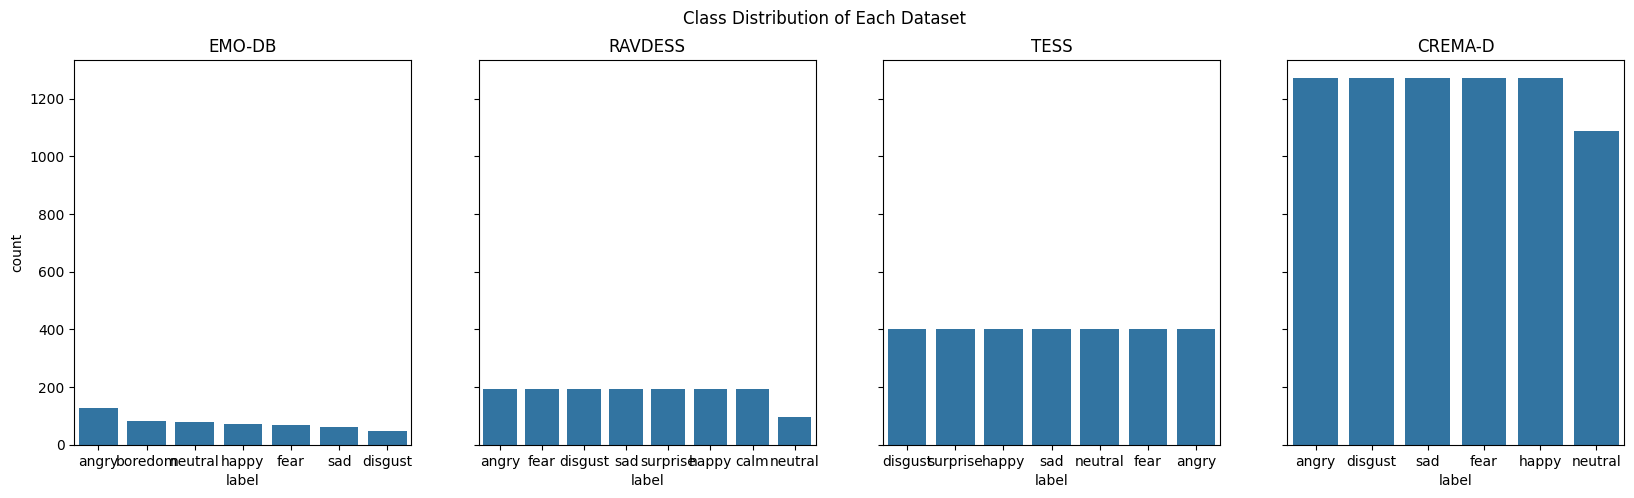

<Figure size 640x480 with 0 Axes>

In [ ]:
# plot class distribution of each dataset in a row of 4 subplots
import matplotlib.pyplot as plt
import seaborn as sns
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
sns.countplot(x='label', data=emodb, ax=axes[0], order=emodb['label'].value_counts().index)
axes[0].set_title('EMO-DB')
sns.countplot(x='label', data=ravdess, ax=axes[1], order=ravdess['label'].value_counts().index)
axes[1].set_title('RAVDESS')
sns.countplot(x='label', data=tess, ax=axes[2], order=tess['label'].value_counts().index)
axes[2].set_title('TESS')
sns.countplot(x='label', data=crema, ax=axes[3], order=crema['label'].value_counts().index)
axes[3].set_title('CREMA-D')
plt.suptitle('Class Distribution of Each Dataset')
plt.show()
plt.savefig('countplots.png')

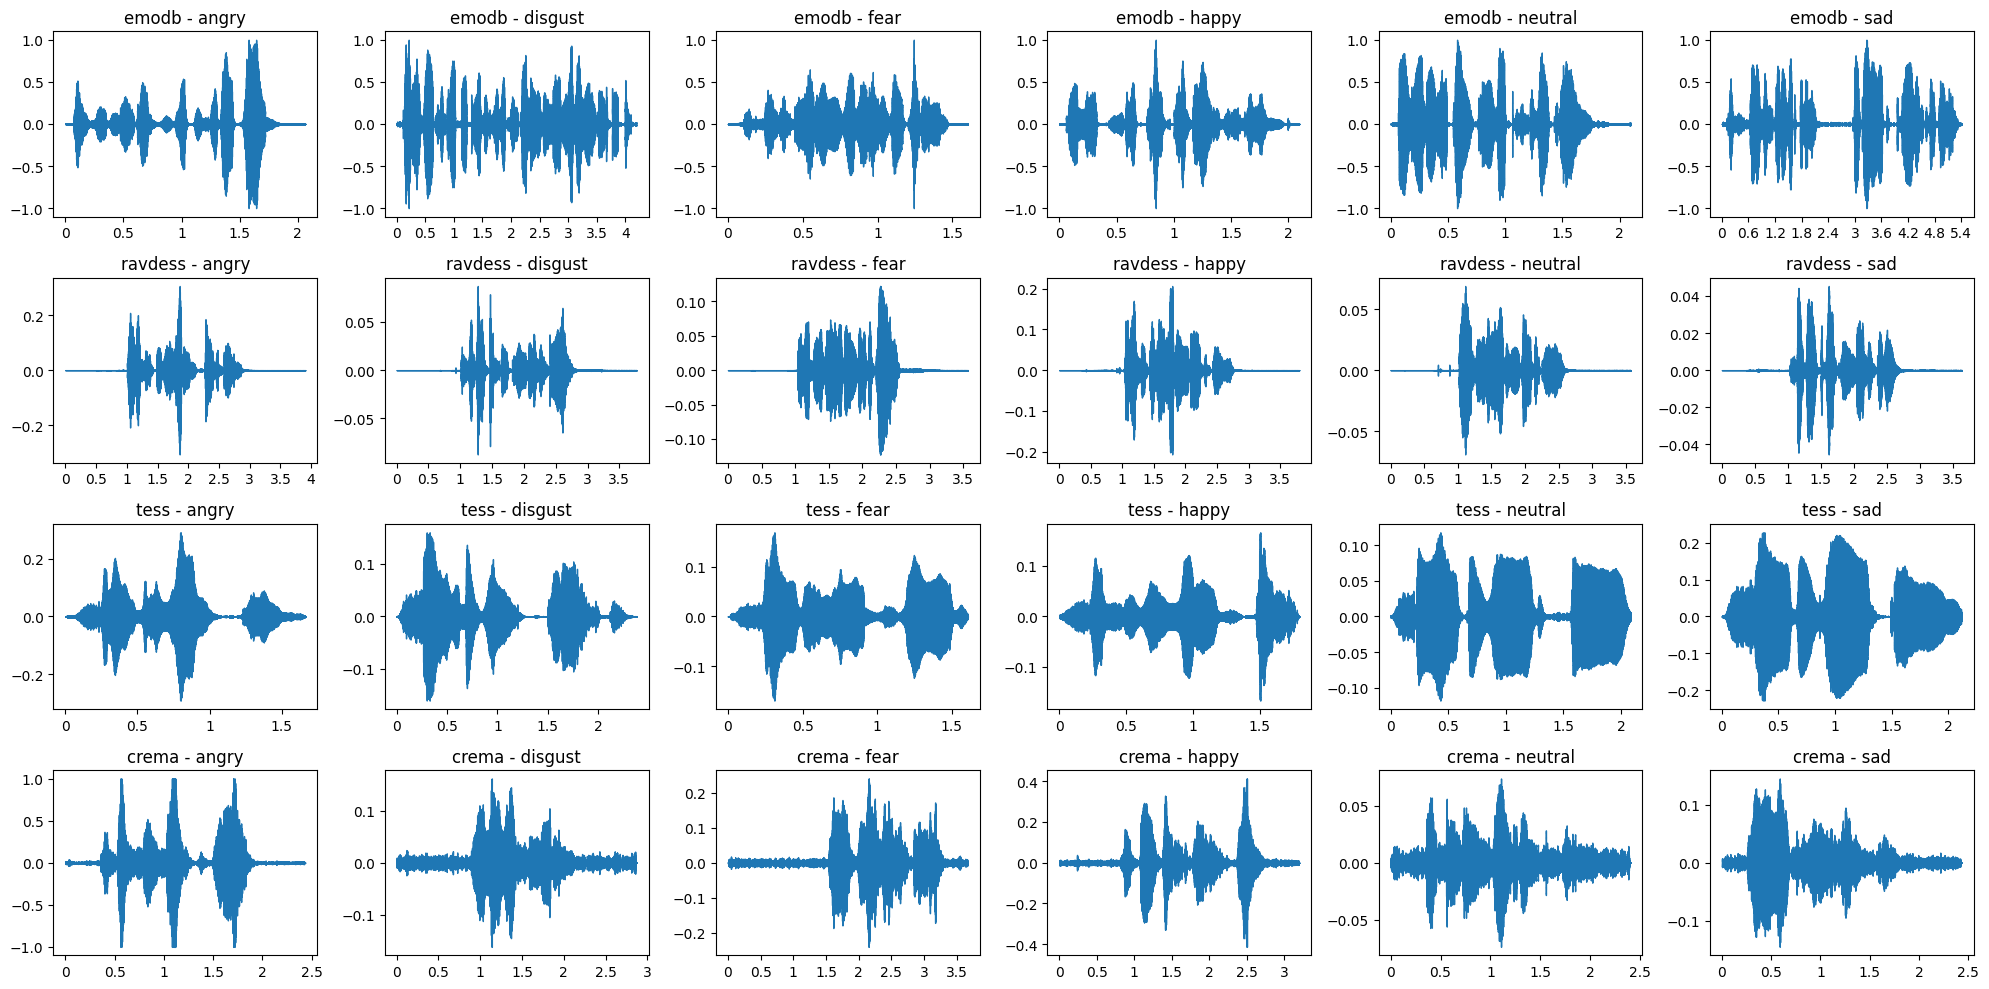

In [4]:
# plot a waveform of each emotion for each dataset (4 rows, 7 columns)
import matplotlib.pyplot as plt
import librosa.display
fig, axs = plt.subplots(4, 6, figsize=(20, 10))
for i, dataset in enumerate([emodb, ravdess, tess, crema]):
    for j, emotion in enumerate(['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad']):#, 'surprise']):
        # get the first sample of the emotion
        sample = dataset[dataset['label'] == emotion].iloc[0]
        # load the audio file
        y, sr = librosa.load(sample['filename'], sr=None)
        # plot the waveform
        librosa.display.waveshow(y, sr=sr, ax=axs[i, j])
        axs[i, j].set_title(f'{dataset["dataset"].iloc[0]} - {emotion}')
        axs[i, j].set_xlabel('')
        axs[i, j].set_ylabel('')
plt.tight_layout()
plt.savefig('waveforms.png')
plt.show()

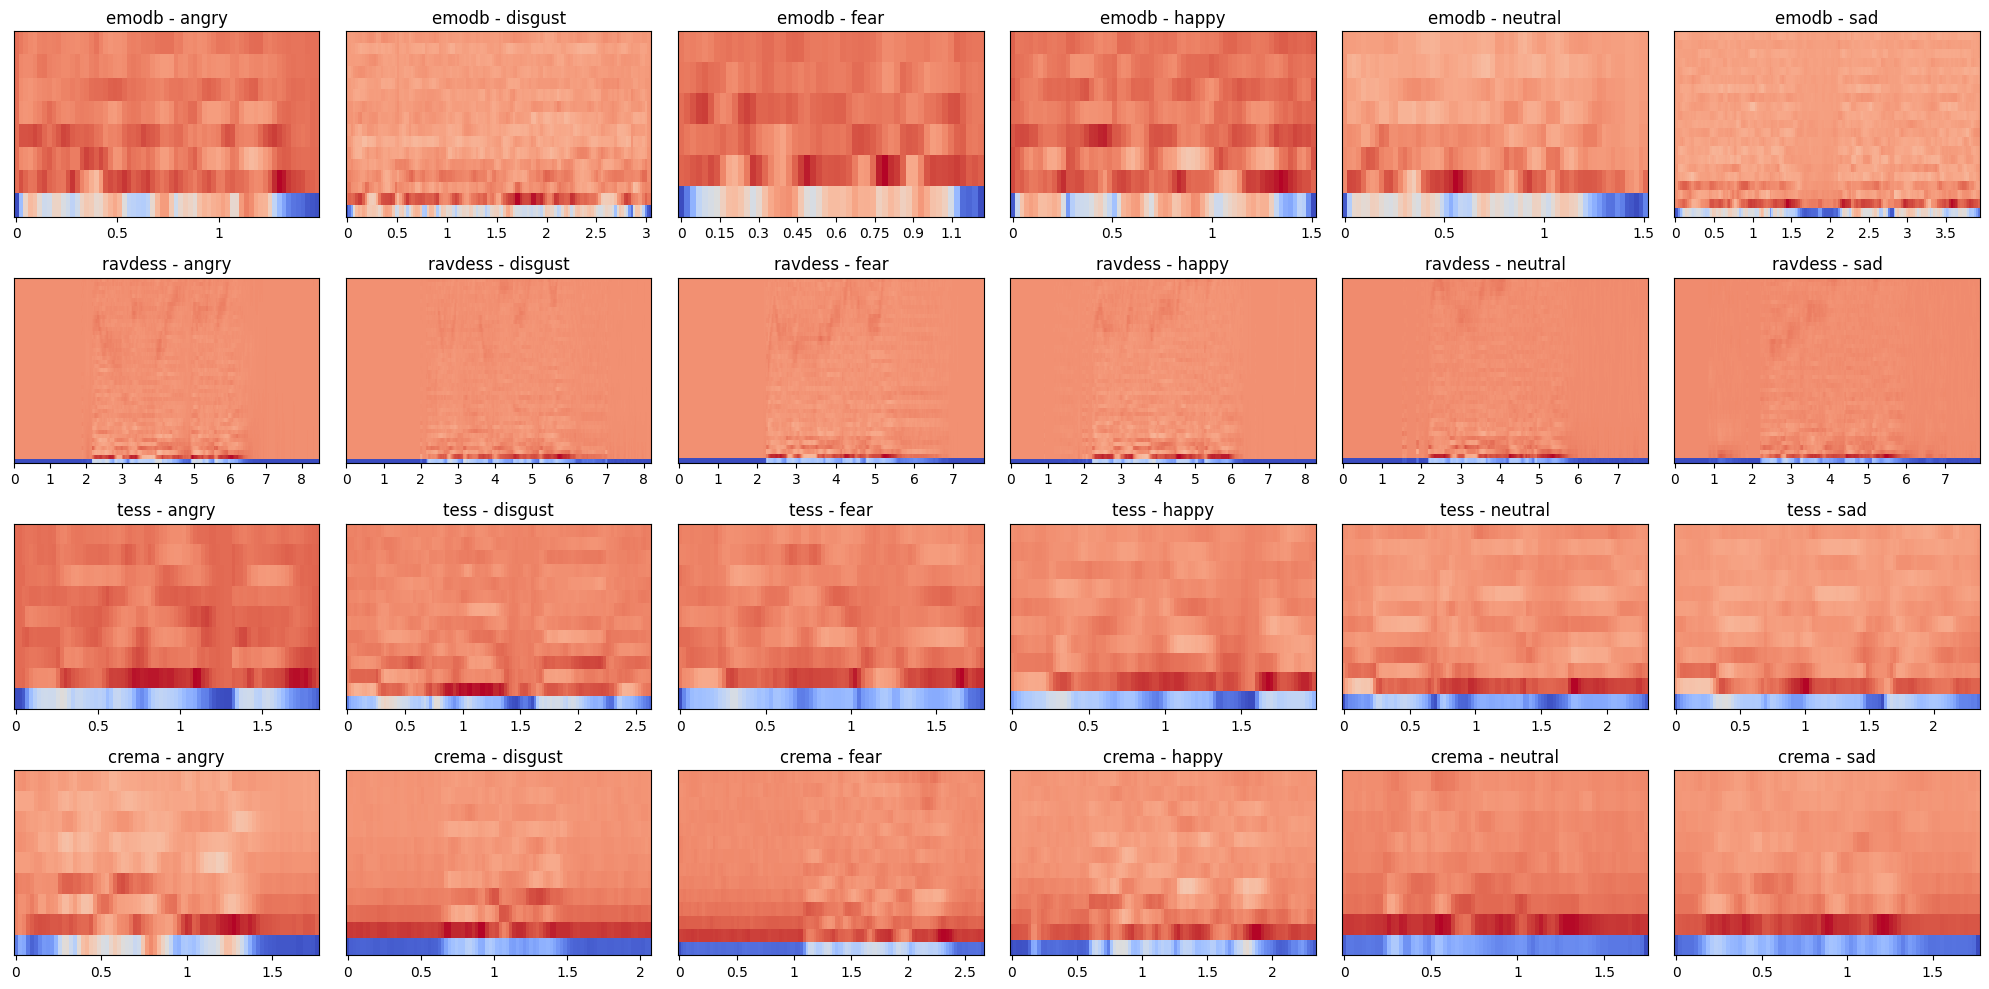

In [22]:
# plot mfcc of each emotion for each dataset (4 rows, 6 columns)
import matplotlib.pyplot as plt
import librosa.display
fig, axs = plt.subplots(4, 6, figsize=(20, 10))
for i, dataset in enumerate([emodb, ravdess, tess, crema]):
    for j, emotion in enumerate(['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad']):#, 'surprise']):
        # get the first sample of the emotion
        sample = dataset[dataset['label'] == emotion].iloc[0]
        # load the audio file
        y, sr = librosa.load(sample['filename'], sr=None)
        # compute mfcc
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=len(y)//4096)
        # plot the mfcc
        img = librosa.display.specshow(mfccs, x_axis='time', ax=axs[i, j])
        axs[i, j].set_title(f'{dataset["dataset"].iloc[0]} - {emotion}')
        axs[i, j].set_xlabel('')
        axs[i, j].set_ylabel('')
plt.tight_layout()
plt.savefig('mfccs-resized.png')
plt.show()

/Users/sofiafernandes/miniconda3/envs/varm/lib/python3.8/site-packages/librosa/feature/spectral.py:2143: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)


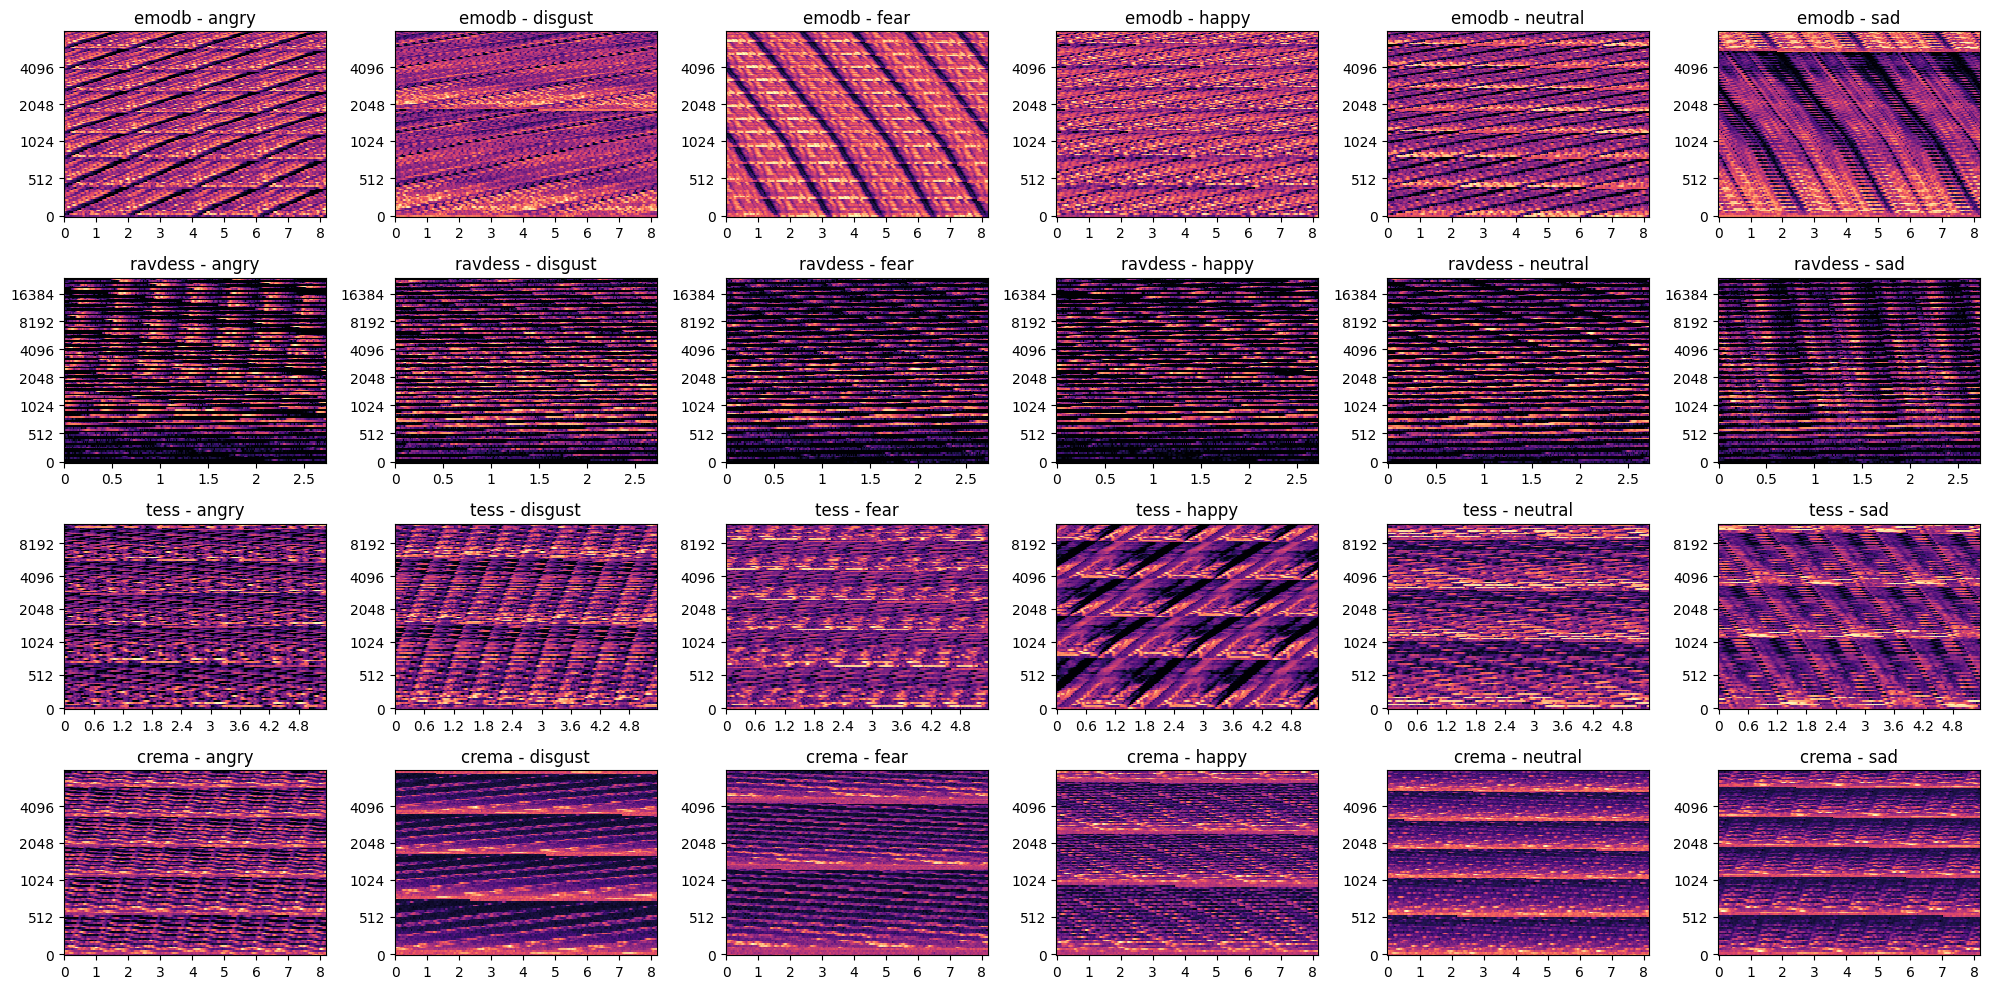

In [25]:
# plot spectrogram of each emotion for each dataset (4 rows, 6 columns)
import matplotlib.pyplot as plt
import librosa.display
fig, axs = plt.subplots(4, 6, figsize=(20, 10))
for i, dataset in enumerate([emodb, ravdess, tess, crema]): 
    for j, emotion in enumerate(['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad']):#, 'surprise']):
        # get the first sample of the emotion
        sample = dataset[dataset['label'] == emotion].iloc[0]
        # load the audio file
        y, sr = librosa.load(sample['filename'], sr=None)
        # compute spectrogram
        S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=len(y)//512)#128)
        S_dB = librosa.power_to_db(S, ref=np.max)

        S_dB_resized = np.resize(S_dB, (128, 256))
        # plot the spectrogram
        img = librosa.display.specshow(S_dB_resized, x_axis='time', y_axis='mel', sr=sr, ax=axs[i, j])
        axs[i, j].set_title(f'{dataset["dataset"].iloc[0]} - {emotion}')
        axs[i, j].set_xlabel('')
        axs[i, j].set_ylabel('')
plt.tight_layout()
plt.savefig('spectrograms.png')
plt.show()

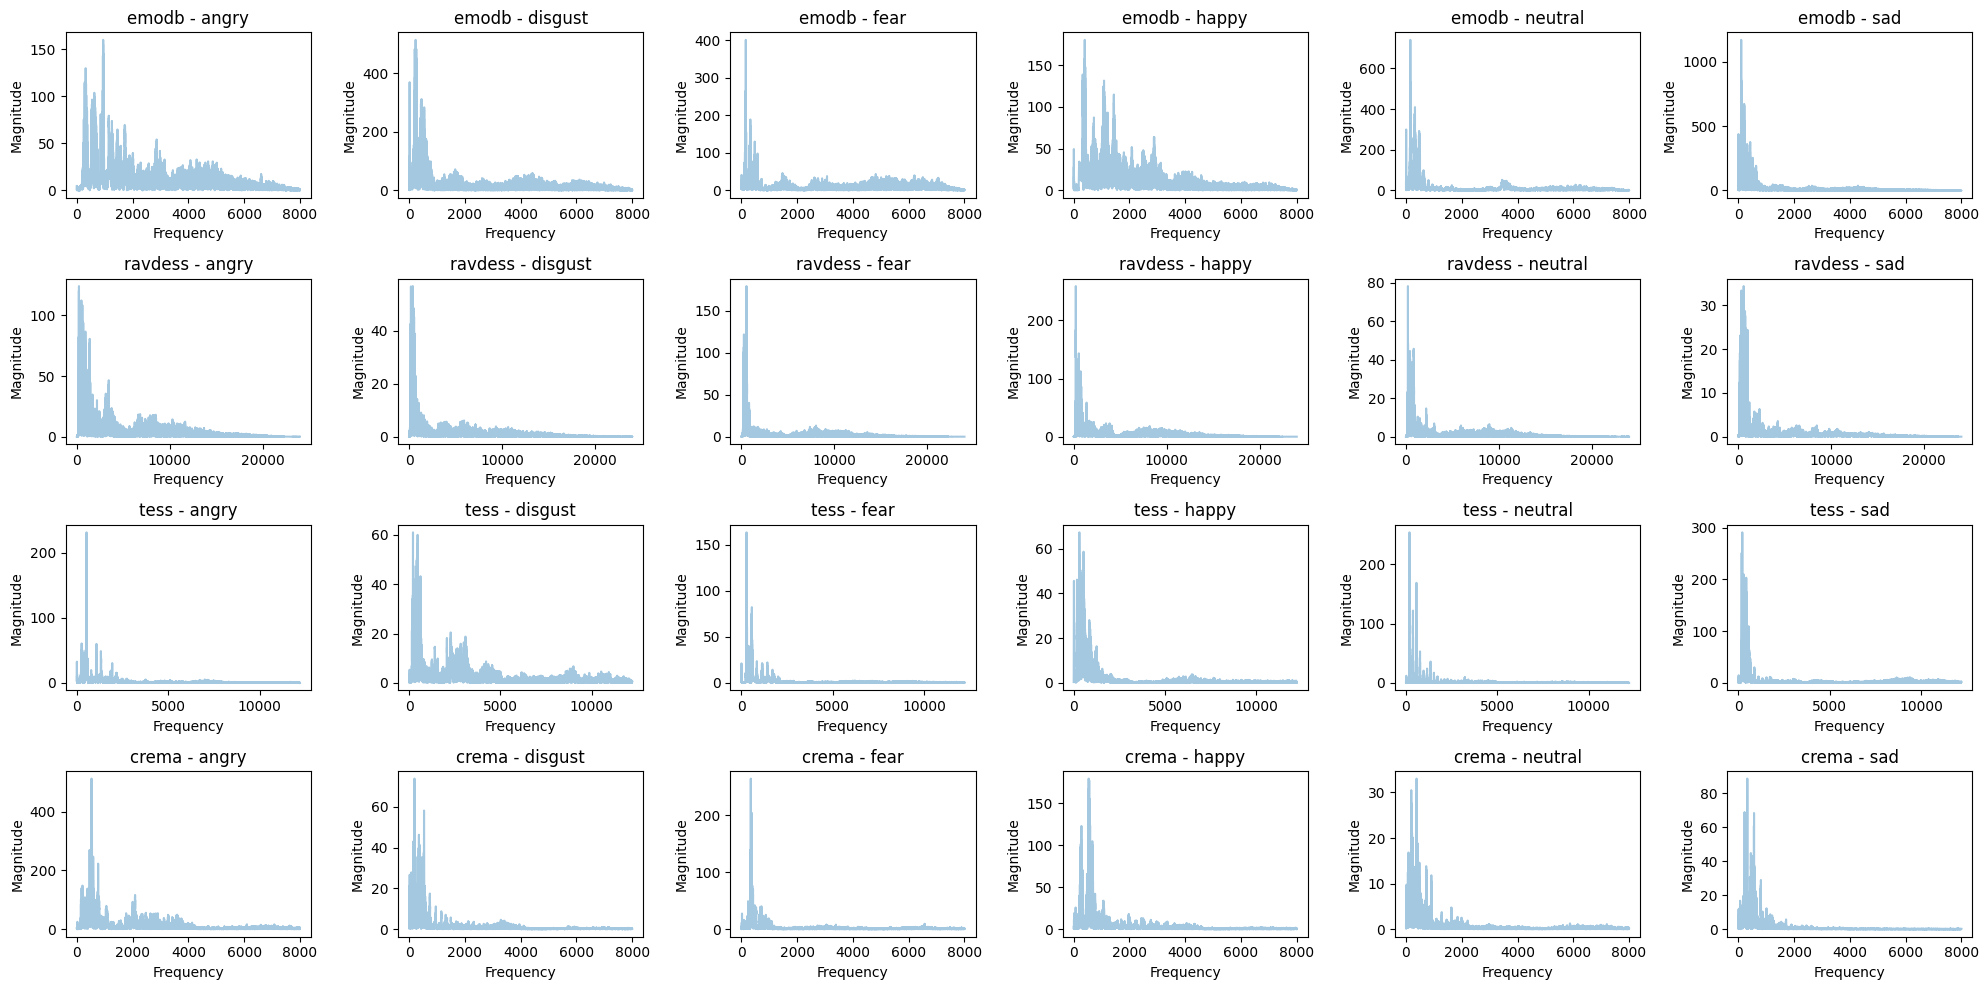

In [10]:

# plot power spectrum for each emotion for each dataset (4 rows, 6 columns), dont need imports, based on above
fig, axs = plt.subplots(4, 6, figsize=(20, 10))
for i, dataset in enumerate([emodb, ravdess, tess, crema]): 
    for j, emotion in enumerate(['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad']):#, 'surprise']):
        # get the first sample of the emotion
        sample = dataset[dataset['label'] == emotion].iloc[0]
        # load the audio file
        y, sr = librosa.load(sample['filename'], sr=None)
        # compute fft
        fft = np.fft.fft(y)
        spectrum = np.abs(fft)
        f = np.linspace(0, sr, len(spectrum))
        left_spectrum = spectrum[:int(len(spectrum)/2)]
        left_f = f[:int(len(spectrum)/2)]
        # plot the power spectrum
        axs[i, j].plot(left_f, left_spectrum, alpha=0.4)
        axs[i, j].set_title(f'{dataset["dataset"].iloc[0]} - {emotion}')
        axs[i, j].set_xlabel('Frequency')
        axs[i, j].set_ylabel('Magnitude')
plt.tight_layout()
plt.savefig('power_spectrums.png')
plt.show()

/var/folders/0s/lm29041s6hv5pq_lc3jblq540000gn/T/ipykernel_75860/3893080447.py:10: RuntimeWarning: divide by zero encountered in log
  S = np.log(np.abs(librosa.stft(y)))


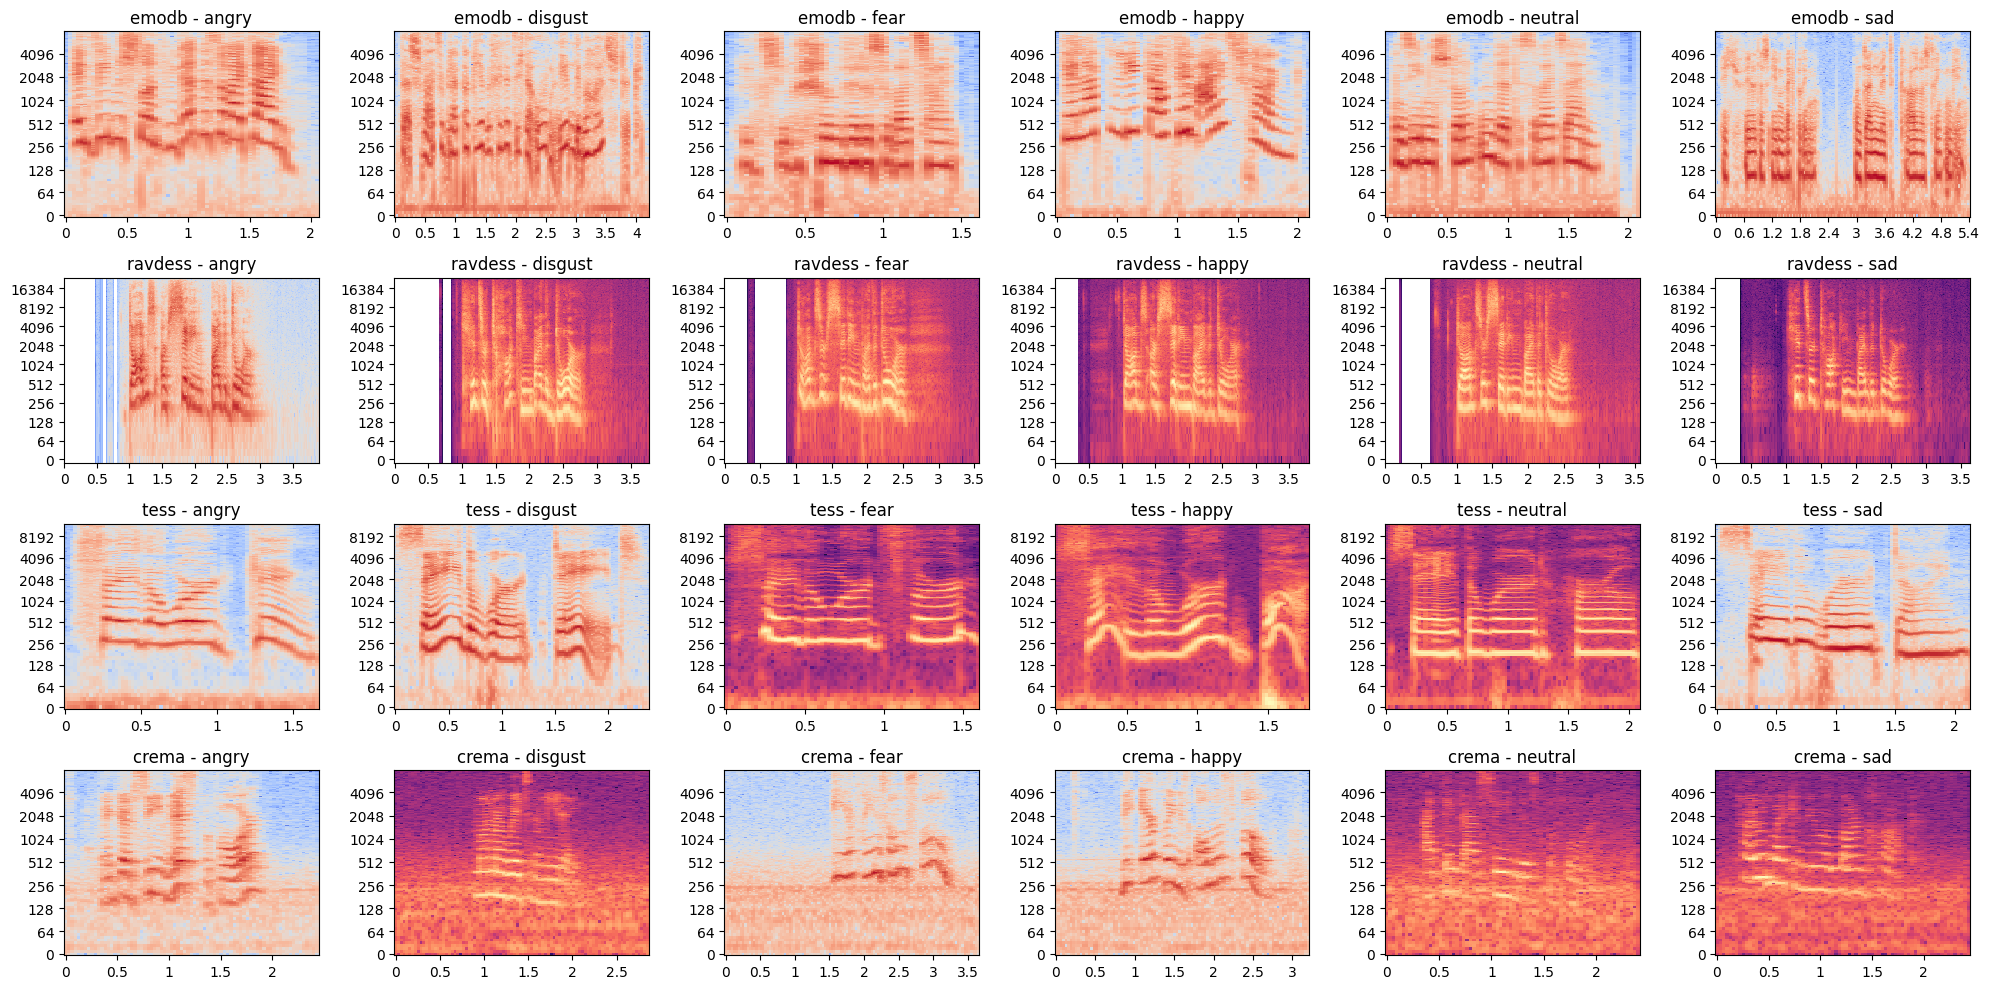

In [27]:

# plot short fourier transform for each emotion for each dataset (4 rows, 6 columns), dont need imports, based on above
fig, axs = plt.subplots(4, 6, figsize=(20, 10))
for i, dataset in enumerate([emodb, ravdess, tess, crema]): 
    for j, emotion in enumerate(['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad']):#, 'surprise']):
        # get the first sample of the emotion
        sample = dataset[dataset['label'] == emotion].iloc[0]
        # load the audio file
        y, sr = librosa.load(sample['filename'], sr=None)
        # compute stft
        S = np.log(np.abs(librosa.stft(y)))
        S_resized = np.resize(S, (128, 256))
        # plot the stft
        img = librosa.display.specshow(S, x_axis='time', y_axis='log', sr=sr, ax=axs[i, j])
        axs[i, j].set_title(f'{dataset["dataset"].iloc[0]} - {emotion}')
        axs[i, j].set_xlabel('')
        axs[i, j].set_ylabel('')
plt.tight_layout()
plt.savefig('stft-log-resized.png')
plt.show()
